In [1]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from plotting_utils import FlatmapMapper, FigureConfig, FlatmapPlotter, SingleCorrelationStrategy, LoserTakesItAllStrategy

from pathlib import Path
root_dir = Path('../')
sys.path.append('../')
from data_loading import (
    DataSequence, ContextManager, EmbeddingManager, 
    file_io, config, prepare_data, preprocessing
)


/Users/simoneesposito/Desktop/Uni/WiSe 25_26 FINAL BOSS/nonsense/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_significant_voxels(results, mode):
    sig = np.array(results[mode]['r'])
    sig[results[mode]['fdr']['r']['excluded_voxels_indices']] = np.nan
    return sig

## FLATMAPS

In [45]:
subject_code = {
    'subject01': 'S1',
    'subject02': 'S2',
    'subject03': 'S3',
    'subject04': 'S4',
    'subject05': 'S5',
    'subject06': 'S6',
    'subject07': 'S7',
    'subject08': 'S8',
    'subject09': 'S9',
}
def plot_bivariate(
    modality, 
    subject, 
    results_dir, 
    output_dir, 
    output_filename, 
    title='',
    legend=False
):
    results = file_io.load_results(
            root_dir / config.OUTPUT_DIR / results_dir,
            modality,
            subject
        )
    baseline = get_significant_voxels(results, 'baseline')
    if 'masks' in results_dir:
        nouns = baseline-get_significant_voxels(results, 'noun')
        verbs = baseline-get_significant_voxels(results, 'verb')
    else:
        nouns = baseline - get_significant_voxels(results, 'remove-pos-noun')
        verbs = baseline - get_significant_voxels(results, 'remove-pos-verb')
    
    
    # baseline = results['baseline']['r']
    # nouns = baseline - results['remove-pos-noun']['r']
    # verbs = baseline - results['remove-pos-verb']['r']
    from plotting_utils import BivariateStrategy
    fig_config = FigureConfig(
        figsize=(250/72, 150/72),
        smooth=False,
        show=True,
        show_regions=False,
        save= True,
        output_dir=output_dir
    )
    mapper = FlatmapMapper(subject, root_dir/config.MAPPER_PATH)
    plotter = FlatmapPlotter(mapper, fig_config)
    _ = plotter.plot(
        [nouns, verbs],

        strategy=BivariateStrategy(vmax=0.15, labels=['nouns', 'verbs']),
        output_filename = output_filename,
        title=title,
        subject=subject_code[subject],
        builder_kwargs = {'show_legend': legend},
        background_color = (0,0,0)
    )

def plot_colored(modality, subject, results_dir, output_dir, output_filename, title=""):
    results = file_io.load_results(
            root_dir / config.OUTPUT_DIR / results_dir,
            modality,
            subject
        )
    # baseline = get_significant_voxels(results, 'baseline')
    # nouns = baseline - get_significant_voxels(results, 'remove-pos-noun')
    # verbs = baseline - get_significant_voxels(results, 'remove-pos-verb')

    # baseline = results['baseline']['r']
    # nouns = results['remove-pos-noun']['r']
    # verbs = results['remove-pos-verb']['r']
    # adj = results['remove-pos-adj']['r']
    # adv = results['remove-pos-adv']['r']
    # pron = results['remove-pos-pron']['r']
    # intj = results['remove-pos-intj']['r']
    
    baseline = get_significant_voxels(results, 'baseline')
    nouns = get_significant_voxels(results, 'remove-pos-noun')
    verbs = get_significant_voxels(results, 'remove-pos-verb')
    adj = get_significant_voxels(results, 'remove-pos-adj')
    adv = get_significant_voxels(results, 'remove-pos-adv')
    pron = get_significant_voxels(results, 'remove-pos-pron')
    intj = get_significant_voxels(results, 'remove-pos-intj')

    fig_config = FigureConfig(
        figsize=(250/72, 150/72),
        smooth=False,
        show=True,
        show_regions=False,
        save= True,
        output_dir=output_dir
    )
    mapper = FlatmapMapper(subject, root_dir/config.MAPPER_PATH)
    plotter = FlatmapPlotter(mapper, fig_config)
    _ = plotter.plot(
        [nouns, verbs, adj, adv, pron, intj, baseline],
        strategy=LoserTakesItAllStrategy(names=['Nouns', 'Verbs', 'Adjectives', 'Adverbs', 'Pronouns', 'Interjections']),
        output_filename = output_filename,
        builder_kwargs = {'show_legend': False},
        title = title,
        subject=subject_code[subject],
        #background_color = (0,0,0)
    )

def plot_heatmap(modality, subject, mode, results_dir, output_dir, output_filename, title=''):
    results = file_io.load_results(
            root_dir / config.OUTPUT_DIR / results_dir,
            modality,
            subject
        )
    data = get_significant_voxels(results, mode)
    fig_config = FigureConfig(
        figsize=(12, 8),
        smooth=False,
        show=False,
        show_regions=True,
        save= True,
        output_dir=output_dir
    )
    mapper = FlatmapMapper(subject, root_dir/config.MAPPER_PATH)
    plotter = FlatmapPlotter(mapper, fig_config)
    _ = plotter.plot(
        [data],
        strategy=SingleCorrelationStrategy(),
        output_filename = output_filename,
        title=title,
        subject=subject_code[subject],
        builder_kwargs = {'show_legend': True},
        background_color = (0,0,0)
    )

### Contextual verb vs noun

Saved to ../outputs/FIGURES/Fig1/subject07-listening-all.pdf


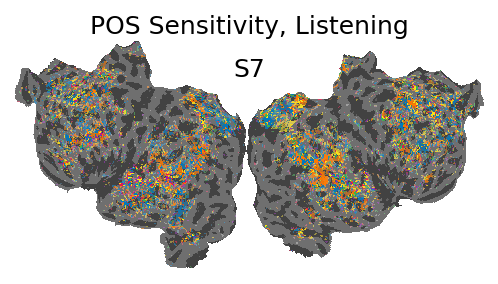

In [ ]:
plot_colored(
    modality='listening',
    subject='subject07',
    results_dir='results',
    output_dir = root_dir / 'docs'/'figures',
    output_filename='subject07-listening-all.pdf',
    title = 'POS Sensitivity, Listening',
)

In [31]:
plot_heatmap(
    modality='listening',
    subject='subject07',
    mode='verb',
    results_dir='results_masks',
    output_dir=root_dir / config.OUTPUT_DIR / "FIGURES"/'S7',
    output_filename=f"hmm-verb.png",
    title="Listening Baseline (r)"
)

Saved to ../outputs/FIGURES/S7/hmm-verb.png


In [ ]:
file_io.load_features('trn', config.FEATURES_FILE, )

Saved to ../outputs/FIGURES/S7/subject07-reading-masked.pdf


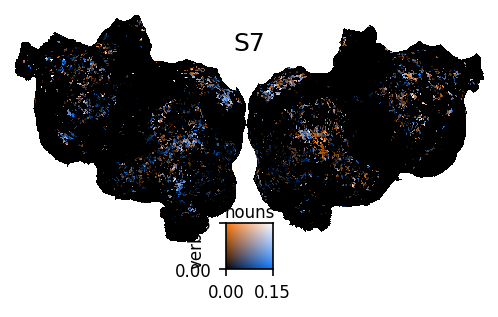

In [50]:
modality='reading'
plot_bivariate(
    modality=modality,
    subject='subject07',
    results_dir="results_masks",
    output_dir = root_dir / config.OUTPUT_DIR / "FIGURES"/'S7',
    output_filename=f'subject07-{modality}-masked.pdf',
    #title = 'Noun-Masking vs Verb-Masking',
    legend = True
)


Saved to ../outputs/FIGURES/masked/subject01-reading.pdf


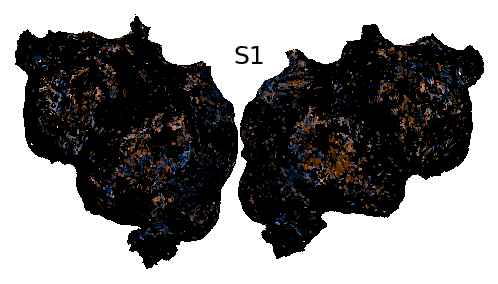

Saved to ../outputs/FIGURES/masked/subject02-reading.pdf


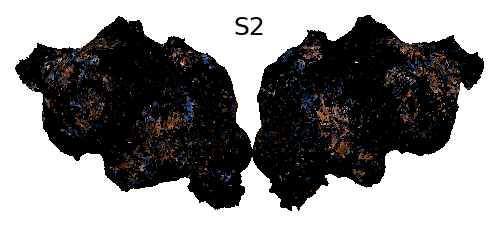

Saved to ../outputs/FIGURES/masked/subject03-reading.pdf


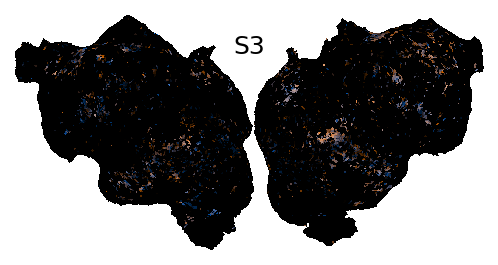

Saved to ../outputs/FIGURES/masked/subject04-reading.pdf


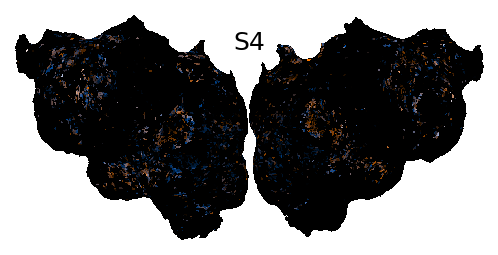

Saved to ../outputs/FIGURES/masked/subject05-reading.pdf


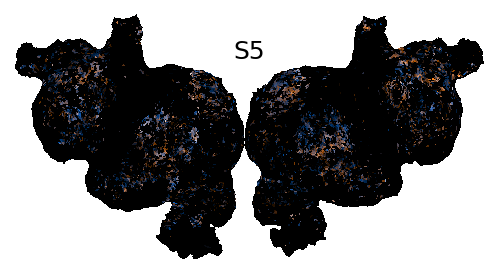

Saved to ../outputs/FIGURES/masked/subject06-reading.pdf


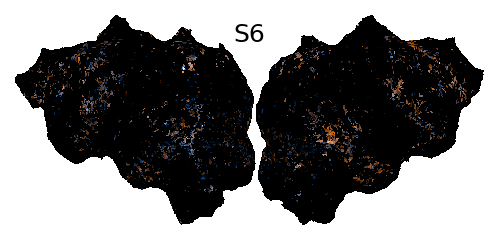

Saved to ../outputs/FIGURES/masked/subject07-reading.pdf


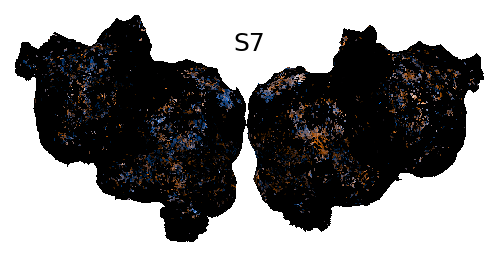

Saved to ../outputs/FIGURES/masked/subject08-reading.pdf


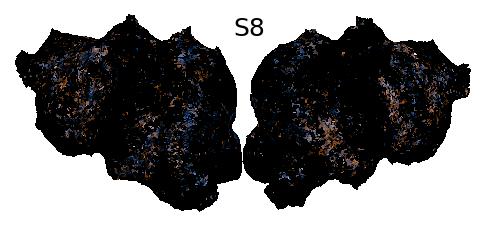

Error plotting subject09 reading: 'baseline'


In [54]:
for subject in config.SUBJECTS:
    try:
        plot_bivariate(
            modality='reading',
            subject=subject,
            results_dir='results',
            output_dir = root_dir / config.OUTPUT_DIR / "FIGURES" / 'masked',
            output_filename = f'{subject}-reading.pdf',
            legend = False
        )
    except Exception as e:
        print(f"Error plotting {subject} reading: {e}")
        

### Lexical verb vs noun

In [ ]:
for subject in config.SUBJECTS[6:7]:
    if subject == 'subject04':
        continue
    results = file_io.load_results(
            root_dir / config.OUTPUT_DIR / "results_control",
            'listening',
            subject
        )
    baseline = get_significant_voxels(results, 'baseline')
    nouns = baseline - get_significant_voxels(results, 'remove-pos-pct-noun')
    verbs = baseline - get_significant_voxels(results, 'remove-pos-pct-verb')
    
    # baseline = results['baseline']['r']
    # nouns = baseline - results['remove-pos-pct-noun']['r']
    # verbs = baseline - results['remove-pos-pct-verb']['r']
    from plotting_utils import BivariateStrategy
    fig_config = FigureConfig(
        figsize=(12, 8),
        smooth=False,
        show=True,
        show_regions=True,
        save= False,
        output_dir=root_dir / config.IMAGES_DIR/ modality / "Lexical2D"
    )
    mapper = FlatmapMapper(subject, root_dir/config.MAPPER_PATH)
    plotter = FlatmapPlotter(mapper, fig_config)
    _ = plotter.plot(
        [nouns, verbs],

        strategy=BivariateStrategy(vmax=0.1, labels=['nouns', 'verbs']),
        title = f'Nouns vs Verbs | {subject} | Lexical',
        output_filename = f'{subject}.png'
    )

## BAR PLOT

In [27]:
import spacy
import matplotlib.pyplot as plt
from collections import defaultdict

def analyze_pos(text, pos_tags):
    """Analyze parts of speech in text and return percentages."""
    doc = nlp(text)
    pos_counts = defaultdict(int)
    
    for token in doc:
        if token.pos_ in pos_tags:
            pos_counts[token.pos_] += 1
    
    total = sum(pos_counts.values())
    
    percentages = {tag: (pos_counts[tag] / total * 100) if total > 0 else 0 for tag in pos_tags}
    
    return percentages

In [28]:
nlp = spacy.load("en_core_web_sm")

# Sample stories (replace with your actual data)
stories = file_io.load_dataseqs(root_dir / config.DATASEQ_PATH, config.STORIES)
stories = {'story ' + str(i): ' '.join(v.data) for i, v in enumerate(stories.values())}

In [29]:
pos = {}
pos_tags = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'INTJ', 'PROPN', 'AUX']
for story_name, text in stories.items():
    pos[story_name] = analyze_pos(text, pos_tags)

# Prepare data for plotting
story_names = list(pos.keys())
nouns = [pos[s]["NOUN"]+pos[s]["PROPN"] for s in story_names]
verbs = [pos[s]["VERB"]+pos[s]["AUX"] for s in story_names]
adjectives = [pos[s]["ADJ"] for s in story_names]
adverbs = [pos[s]["ADV"] for s in story_names]
pronouns = [pos[s]["PRON"] for s in story_names]
interjections = [pos[s]["INTJ"] for s in story_names]

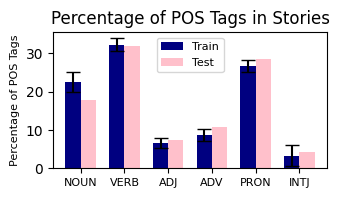

In [60]:
# Create bar chart that shows the percentage (y-axis) of each POS tag (x-axis) with its standard deviation (error bars)
# it should show two bars per POS tag: one for the average percentage across all stories except the last one, and one for the last story
import numpy as np
labels = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'INTJ']
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars
averages = [
    np.mean(nouns[:-1]), 
    np.mean(verbs[:-1]), 
    np.mean(adjectives[:-1]), 
    np.mean(adverbs[:-1]), 
    np.mean(pronouns[:-1]), 
    np.mean(interjections[:-1])
]
std_devs = [
    np.std(nouns[:-1]), 
    np.std(verbs[:-1]),
    np.std(adjectives[:-1]),
    np.std(adverbs[:-1]),
    np.std(pronouns[:-1]),
    np.std(interjections[:-1])
]
last_story = [
    nouns[-1],
    verbs[-1],
    adjectives[-1],
    adverbs[-1],
    pronouns[-1],
    interjections[-1]
]
fig, ax = plt.subplots(figsize=(250/72, 150/72))
rects1 = ax.bar(x - width/2, averages, width, yerr=std_devs, label='Train', capsize=5, color='navy')
rects2 = ax.bar(x + width/2, last_story, width, label='Test', color='pink')
ax.set_ylabel('Percentage of POS Tags', fontsize=8)
ax.set_title('Percentage of POS Tags in Stories', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.legend(fontsize=8, loc='upper center')
plt.savefig(root_dir / 'docs'/'figures' / 'pos_distribution.pdf', format='pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()

## DROP PLOT

In [ ]:
def compute_margin(corr, baseline):
    stacked = np.stack(corr, axis=0)
    stacked-= baseline
    worst_indices = np.argsort(stacked, axis=0)[0]
    second_worst_indices = np.argsort(stacked, axis=0)[1]

    worst_vals = stacked[worst_indices, np.arange(stacked.shape[1])]
    second_worst_vals = stacked[second_worst_indices, np.arange(stacked.shape[1])]

    margin = second_worst_vals- worst_vals
    return margin

In [ ]:
for subject in [config.SUBJECTS[0], config.SUBJECTS[5], config.SUBJECTS[6]]:
    mapper = FlatmapMapper(subject, root_dir/config.MAPPER_PATH)
    fig_config = FigureConfig(
        figsize=(12, 8), 
        save=True, 
        smooth=True, 
        show=True,
        show_regions=True,
        output_dir=root_dir/config.IMAGES_DIR/modality/"VERBS_NOUNS",
    )
    plotter = FlatmapPlotter(mapper, fig_config)
    results = file_io.load_results(
        root_dir / config.OUTPUT_DIR / "results",
        modality,
        subject
    )
    data = [get_significant_voxels(results, mode) for mode in modes] 
    baseline = get_significant_voxels(results, 'baseline')
    margin = compute_margin(data, baseline)
    pct = np.nanpercentile(margin, 95)
    print(pct)
    _ = plotter.plot(
        data = [margin],
        strategy = SingleCorrelationStrategy(vmax = pct),
        title = title.format(
            title = "Worst vs Second Worst - Significant Voxels", 
            subject=subject, 
            modality=modality,
            context_size = 10
        ),
        output_filename = f'{subject}_margins'
    )